# Anomaly Baseline Visualization

This notebook is intentionally lean.

The goal is to visualize the current anomaly-baseline experiment as it already exists in the repo:

- train Isolation Forest and PyOD LOF on normal-only synthetic data
- inject labeled anomalies into a hold-out split
- compare score separation and evaluation curves

This is a controlled synthetic anomaly experiment, not proof of production anomaly performance.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("Could not locate the project root containing the src directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.anomaly_baseline import run_scored_baseline_experiment
from src.data import load_dataset

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Load the synthetic baseline setup

Keep the data source aligned with the current implementation so the notebook reflects the existing experiment exactly.

In [2]:
RANDOM_STATE = 42
SYNTHETIC_UNITS = 40
SYNTHETIC_TEST_FRACTION = 0.25
HOLDOUT_ANOMALY_FRACTION = 0.08
CONTAMINATION = 0.08
N_NEIGHBORS = 35

train_df, holdout_df, _ = load_dataset(
    data_dir=PROJECT_ROOT / "Data",
    source="synthetic",
    synthetic_units=SYNTHETIC_UNITS,
    synthetic_test_fraction=SYNTHETIC_TEST_FRACTION,
    synthetic_anomaly_fraction=0.0,
    synthetic_random_state=RANDOM_STATE,
)

scored_evaluation_df, results = run_scored_baseline_experiment(
    train_df=train_df,
    holdout_df=holdout_df,
    anomaly_fraction=HOLDOUT_ANOMALY_FRACTION,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_neighbors=N_NEIGHBORS,
)

summary_df = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "holdout_rows",
            "evaluation_rows",
            "injected_anomalies",
            "holdout_anomaly_fraction",
            "isolation_forest_roc_auc",
            "isolation_forest_pr_auc",
            "lof_roc_auc",
            "lof_pr_auc",
        ],
        "value": [
            len(train_df),
            len(holdout_df),
            len(scored_evaluation_df),
            int(scored_evaluation_df["is_anomaly"].sum()),
            HOLDOUT_ANOMALY_FRACTION,
            results["isolation_forest"].roc_auc,
            results["isolation_forest"].pr_auc,
            results["local_outlier_factor"].roc_auc,
            results["local_outlier_factor"].pr_auc,
        ],
    }
)

summary_df

,metric,value
0,train_rows,5341.000000
1,holdout_rows,1476.000000
2,evaluation_rows,1594.000000
3,injected_anomalies,118.000000
4,holdout_anomaly_fraction,0.080000
5,isolation_forest_roc_auc,0.639848
6,isolation_forest_pr_auc,0.188565
7,lof_roc_auc,0.733522
8,lof_pr_auc,0.506025


## 2. Hold-out label composition

First check how many clean and injected rows the evaluation set contains, then inspect the synthetic anomaly types.

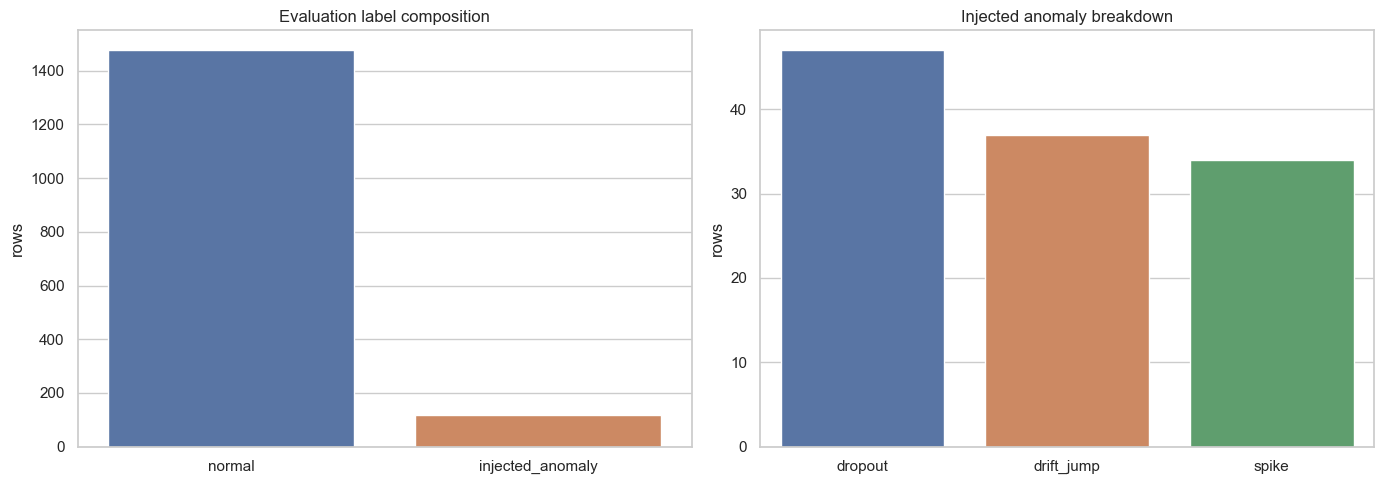

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = (
    scored_evaluation_df["is_anomaly"]
    .map({0: "normal", 1: "injected_anomaly"})
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
sns.barplot(data=label_counts, x="label", y="count", hue="label", legend=False, ax=axes[0])
axes[0].set_title("Evaluation label composition")
axes[0].set_xlabel("")
axes[0].set_ylabel("rows")

anomaly_type_counts = (
    scored_evaluation_df.loc[scored_evaluation_df["is_anomaly"] == 1, "injected_anomaly_type"]
    .value_counts()
    .rename_axis("anomaly_type")
    .reset_index(name="count")
)
sns.barplot(data=anomaly_type_counts, x="anomaly_type", y="count", hue="anomaly_type", legend=False, ax=axes[1])
axes[1].set_title("Injected anomaly breakdown")
axes[1].set_xlabel("")
axes[1].set_ylabel("rows")

plt.tight_layout()
plt.show()

## 3. Sensor-level examples of injected anomalies

Each injected anomaly is created by duplicating a clean hold-out row for the same `unit` and `cycle`, then perturbing a subset of sensors. Plot a few paired examples to see what changed.

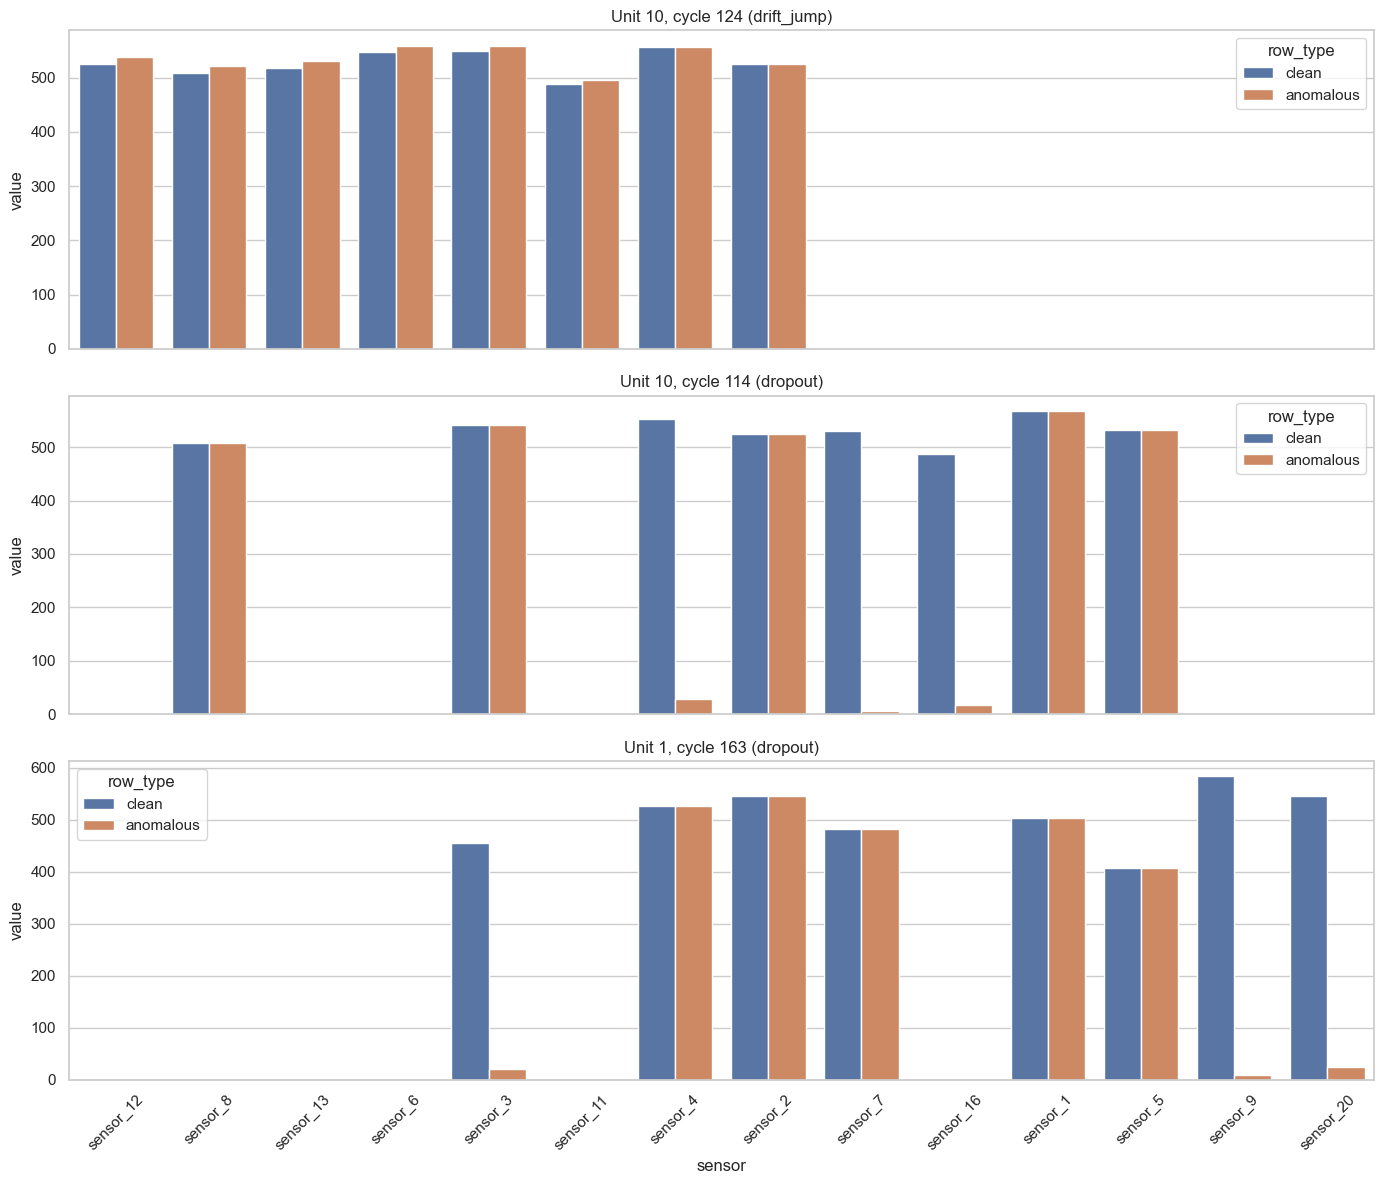

In [4]:
sensor_columns = [column for column in scored_evaluation_df.columns if column.startswith("sensor_")]
selected_anomalies = scored_evaluation_df.loc[scored_evaluation_df["is_anomaly"] == 1].head(3).copy()

fig, axes = plt.subplots(len(selected_anomalies), 1, figsize=(14, 4 * len(selected_anomalies)), sharex=True)
if len(selected_anomalies) == 1:
    axes = [axes]

for ax, (_, anomaly_row) in zip(axes, selected_anomalies.iterrows()):
    clean_pair = scored_evaluation_df[
        (scored_evaluation_df["unit"] == anomaly_row["unit"])
        & (scored_evaluation_df["cycle"] == anomaly_row["cycle"])
        & (scored_evaluation_df["is_anomaly"] == 0)
    ].iloc[0]

    pair_df = pd.DataFrame(
        {
            "sensor": sensor_columns,
            "clean": clean_pair[sensor_columns].to_numpy(dtype=float),
            "anomalous": anomaly_row[sensor_columns].to_numpy(dtype=float),
        }
    )
    pair_df["delta"] = pair_df["anomalous"] - pair_df["clean"]
    top_pair_df = pair_df.reindex(pair_df["delta"].abs().sort_values(ascending=False).index).head(8)
    melted = top_pair_df.melt(id_vars="sensor", value_vars=["clean", "anomalous"], var_name="row_type", value_name="value")

    sns.barplot(data=melted, x="sensor", y="value", hue="row_type", ax=ax)
    ax.set_title(
        f"Unit {int(anomaly_row['unit'])}, cycle {int(anomaly_row['cycle'])} ({anomaly_row['injected_anomaly_type']})"
    )
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4. Score separation by model

Higher scores should correspond to more anomalous rows. These plots show how well each model separates the injected anomalies from clean hold-out rows.

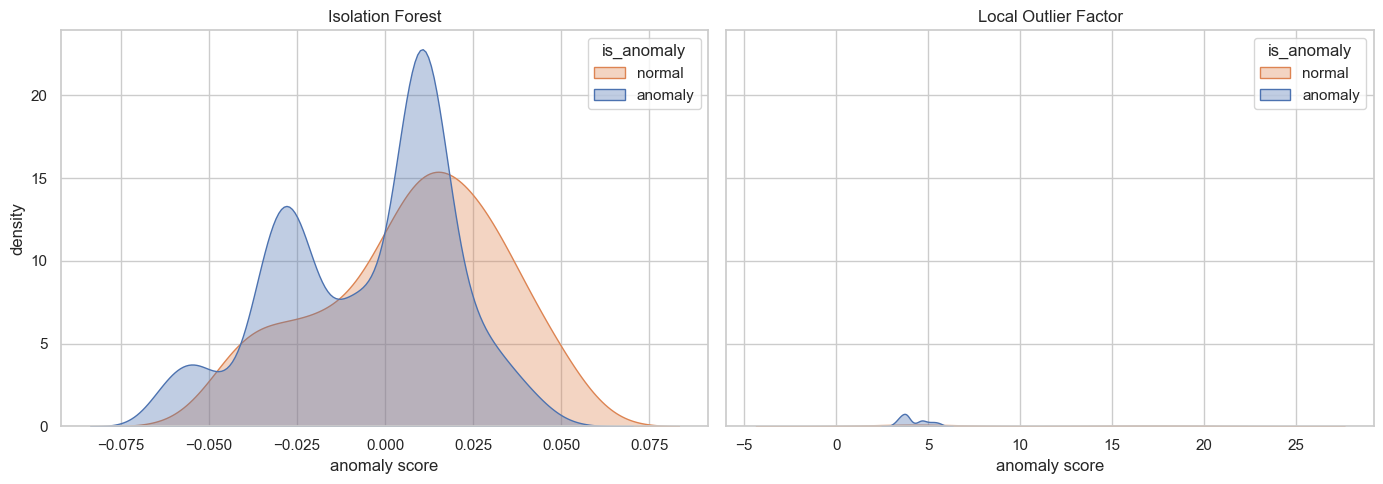

In [5]:
score_specs = [
    ("isolation_forest_score", "Isolation Forest"),
    ("local_outlier_factor_score", "Local Outlier Factor"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (score_column, title) in zip(axes, score_specs):
    sns.kdeplot(
        data=scored_evaluation_df,
        x=score_column,
        hue="is_anomaly",
        common_norm=False,
        fill=True,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("anomaly score")
    ax.legend(title="is_anomaly", labels=["normal", "anomaly"])

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

## 5. ROC and precision-recall curves

Use the per-row scores to compare both baselines directly on the same evaluation set.

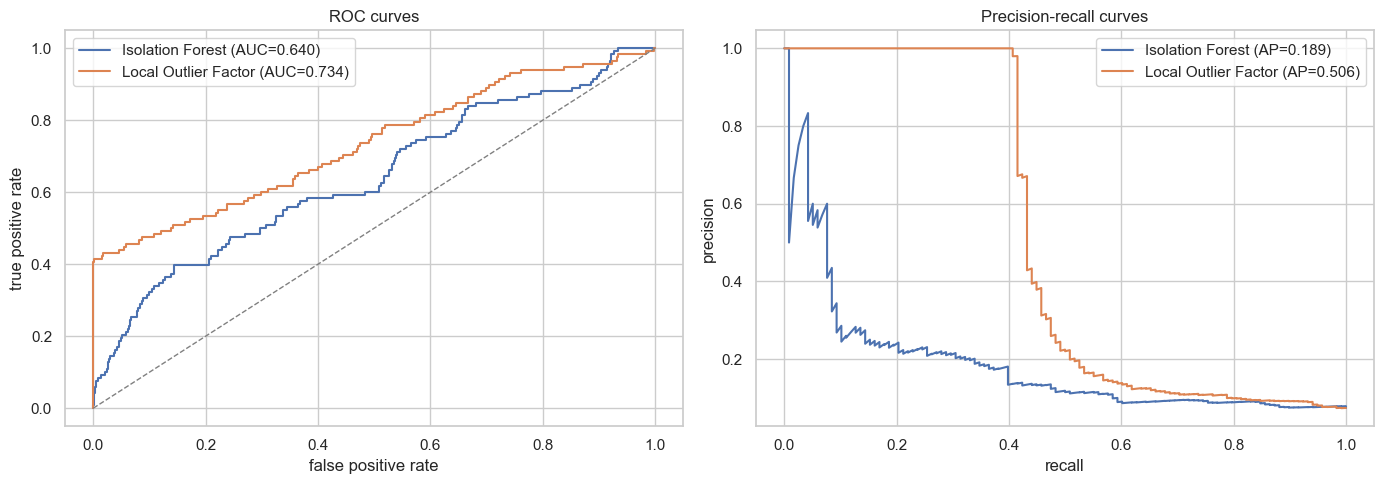

In [6]:
y_true = scored_evaluation_df["is_anomaly"].to_numpy(dtype=int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for score_column, title in score_specs:
    fpr, tpr, _ = roc_curve(y_true, scored_evaluation_df[score_column])
    precision, recall, _ = precision_recall_curve(y_true, scored_evaluation_df[score_column])
    result_key = "isolation_forest" if score_column == "isolation_forest_score" else "local_outlier_factor"
    result = results[result_key]

    axes[0].plot(fpr, tpr, label=f"{title} (AUC={result.roc_auc:.3f})")
    axes[1].plot(recall, precision, label=f"{title} (AP={result.pr_auc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("ROC curves")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].legend()

axes[1].set_title("Precision-recall curves")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Takeaways

On the current synthetic run, LOF should show stronger separation than Isolation Forest if its score distributions and ROC/PR curves dominate. Keep this conclusion narrow: it only applies to this controlled injected-anomaly setup, not to real production telemetry without labels.